### Import packages

In [2]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
%matplotlib inline

### Whole-session event triggered averages - average trace for group with bootstrapped ci

In [3]:
#Load the necessary data - fear conditioning
astro3_fc = onep.InscopixProcessing("astro3", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro4_fc = onep.InscopixProcessing("astro4", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro5_fc = onep.InscopixProcessing("astro5", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro6_fc = onep.InscopixProcessing("astro6", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro7_fc = onep.InscopixProcessing("astro7", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro8_fc = onep.InscopixProcessing("astro8", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro9_fc = onep.InscopixProcessing("astro9", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")
astro10_fc = onep.InscopixProcessing("astro10", "fc", "/Users/suthardr/Desktop/dCA1_Analysis")

astro3_fc.read_inscopix()
astro4_fc.read_inscopix()
astro5_fc.read_inscopix()
astro6_fc.read_inscopix()
astro7_fc.read_inscopix()
astro8_fc.read_inscopix()
astro9_fc.read_inscopix()
astro10_fc.read_inscopix()

In [2]:
#Load the necessary data - recall
astro3_day2 = onep.InscopixProcessing("astro3", "recall", "/Users/suthardr/Desktop/dCA1_Analysis")
astro4_day2 = onep.InscopixProcessing("astro4", "recall", "/Users/suthardr/Desktop/dCA1_Analysis")
astro5_day2 = onep.InscopixProcessing("astro5", "recall", "/Users/suthardr/Desktop/dCA1_Analysis")
astro6_day2 = onep.InscopixProcessing("astro6", "recall", "/Users/suthardr/Desktop/dCA1_Analysis")
astro7_day2 = onep.InscopixProcessing("astro7", "gen1", "/Users/suthardr/Desktop/dCA1_Analysis")
astro8_day2 = onep.InscopixProcessing("astro8", "gen1", "/Users/suthardr/Desktop/dCA1_Analysis")
astro9_day2 = onep.InscopixProcessing("astro9", "gen1", "/Users/suthardr/Desktop/dCA1_Analysis")
astro10_day2 = onep.InscopixProcessing("astro10", "gen1", "/Users/suthardr/Desktop/dCA1_Analysis")

astro3_day2.read_inscopix()
astro4_day2.read_inscopix()
astro5_day2.read_inscopix()
astro6_day2.read_inscopix()
astro7_day2.read_inscopix()
astro8_day2.read_inscopix()
astro9_day2.read_inscopix()
astro10_day2.read_inscopix()

In [4]:
#Transpose dataframes for accepted cells in group1
df = astro3_fc.accepted_traces.transpose()
df1 = astro4_fc.accepted_traces.transpose()
df2 = astro5_fc.accepted_traces.transpose()
df3 = astro6_fc.accepted_traces.transpose()

#Transpose dataframes for accepted cells in group1
df4 = astro7_fc.accepted_traces.transpose()
df5 = astro8_fc.accepted_traces.transpose()
df6 = astro9_fc.accepted_traces.transpose()
df7 = astro10_fc.accepted_traces.transpose()

In [3]:
#Transpose dataframes for accepted cells in group1
df = astro3_day2.accepted_traces.transpose()
df1 = astro4_day2.accepted_traces.transpose()
df2 = astro5_day2.accepted_traces.transpose()
df3 = astro6_day2.accepted_traces.transpose()

#Transpose dataframes for accepted cells in group1
df4 = astro7_day2.accepted_traces.transpose()
df5 = astro8_day2.accepted_traces.transpose()
df6 = astro9_day2.accepted_traces.transpose()
df7 = astro10_day2.accepted_traces.transpose()

In [5]:
timestamps = df.columns.values
timestamps.shape

(3602,)

In [6]:
#Convert to numpy arrays - so it doesn't freak out
numpy = df.to_numpy()
numpy1 = df1.to_numpy()
numpy2 = df2.to_numpy()
numpy3 = df3.to_numpy()
numpy4 = df4.to_numpy()
numpy5 = df5.to_numpy()
numpy6 = df6.to_numpy()
numpy7 = df7.to_numpy()

#Concatenate dataframes for each group - fc
concat_cxta = np.concatenate([numpy[:, :3601], numpy1[:, :3601], numpy2[:, :3601], numpy3[:, :3601]], axis=0)
concat_cxtb = np.concatenate([numpy4[:, :3601], numpy5[:, :3601], numpy6[:, :3601], numpy7[:, :3601]], axis=0)

#Concatenate dataframes for each group
# concat_cxta = np.concatenate([numpy[:, :3303], numpy1[:, :3303], numpy2[:, :3303], numpy3[:, :3303]], axis=0)
# concat_cxtb = np.concatenate([numpy4[:, :3303], numpy5[:, :3303], numpy6[:, :3303], numpy7[:, :3303]], axis=0)

#Create average trace for each group
average_df_cxta = concat_cxta.mean(axis=0)
average_df_cxtb = concat_cxtb.mean(axis=0)

In [7]:
import scipy
from scipy import stats
z_cxta = stats.zscore(concat_cxta, axis=1)
z_cxtb = stats.zscore(concat_cxtb, axis=1)

### Plot all traces for one mouse

### Create figure with average trace for each group (plot one at a time) and ci bootstrapped across all cells pooled together within group

In [8]:
def bci(data, num_samples, cl=0.95):
    """
    Calculate the confidence interval for each time point in the data using bootstrap method.

    data: 2D numpy array, rows represent samples and columns represent time points.
    num_samples: Number of bootstrap samples.
    cl: Confidence level.

    Returns a 2D numpy array containing the lower and upper bound of the confidence interval for each timepoint.
    """
    n, t = data.shape
    ci = np.zeros((2, t))
    rng = np.random.default_rng()

    bootstrap_array = np.zeros(shape=(num_samples, t))

    for i in range(t):
        # Generate bootstrap samples for the current time point
        rints = rng.integers(0, n, num_samples)
        bootstrap_array[:, i] = data[rints, i]

        sig = 1 - cl
        ci[0, :] = np.percentile(bootstrap_array, q=(sig / 2) * 100, axis=0)
        ci[1, :] = np.percentile(bootstrap_array, q=(1 - (sig / 2)) * 100, axis=0)
    return ci

def tci(array, cl=0.95):
    """_summary_

    Args:
        array (_type_): _description_
        cl (float, optional): _description_. Defaults to 0.95.

    Returns:
        _type_: _description_
        """
    n = array.shape[0]
    crit_t = scipy.stats.t.ppf(cl, df=n - 1)
    c_int = np.zeros(shape=(2, array.shape[1]))
    c_int[0, :] = np.mean(array, axis=0) - (crit_t * scipy.stats.sem(array, axis=0))
    c_int[1, :] = np.mean(array, axis=0) + (crit_t * scipy.stats.sem(array, axis=0))
    return c_int


def eta_significance(ci, sig_duration):

        # find deflections from baseline
        deflections = ci > 0

        # create a sliding window for convolution
        window = np.ones(sig_duration)

        # convolve with boolean array
        true_deflects = np.convolve(deflections, window, 'valid')

        # find start indices where convolution equals to significant_duration
        start_indices = np.where(true_deflects == sig_duration)[0]
        return start_indices


def plot_whole_eta(data, ci='bci', sig_duration=8):

    #choose confidence interval type
    if ci == 'tci':
        c_int = tci(data)
    elif ci == 'bci':
        c_int = bci(data, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration=8)

    # create figure
    fig, axs = plt.subplots()
    axs.plot(data.mean(axis=0))
    axs.fill_between(range(c_int.shape[1]), c_int[0, :], c_int[1, :], alpha=0.3)
    axs.set_xlabel('Time (seconds)')
    axs.set_ylabel(r'$\frac{dF}{F}$ (%)')
    axs.grid(False)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    # plot the significant deflections
    y_height = axs.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        axs.hlines(y=y_height, xmin=start_index, xmax=end_index, colors='r')
    return axs

<Axes: xlabel='Time (seconds)', ylabel='$\\frac{dF}{F}$ (%)'>

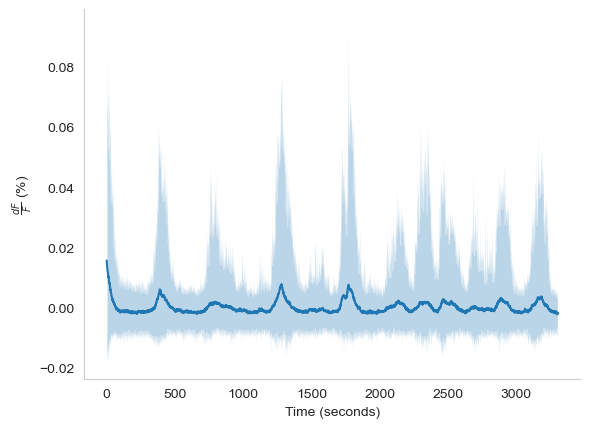

In [34]:
#Plot eta for each group on the same plot
plot_whole_eta(concat_cxta)
#plot_whole_eta(concat_cxtb)

### Raster plot -for entire group

In [10]:
def raster_plot(raster_array, xtick_range=None, xtick_freq=None):
    """Raster plot: Generate a raster plot of Z-scored fiber photometry traces.
    Args: task (str): String that represents the task e.g. FC, Recall, Ext etc.Should be identical to what was
    passed in fiberPhotometryCurve.
    treatment (str): String that represents the treatment e.g. eYFP, ChR2, Shock etc. Should be identical to what
    was passed in fiberPhotometryCurve.
    region (str): String to grab region trace of choice e.g. Region0G, Region1R, etc.
    xtick_range (int, optional): Length in time of session. Defaults to None.
    xtick_freq (int, optional): How many labels in [0, xtick_range]; end points inclusive. Defaults to None.
    Returns: matplotlib figure: a matplotlib figure object matplotlib axis: a matplotlib axis object
    """
    fig, ax = plt.subplots()
    sns.heatmap(raster_array, cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"}, center=0, yticklabels=False, ax=ax, cmap='icefire')
    ax.set_xlabel('Time (s)')
    if xtick_range and xtick_freq is not None:
        ax.set_xticks(np.linspace(0, raster_array.shape[1], xtick_freq),
                          labels=np.linspace(0, xtick_range, xtick_freq))
    return fig, ax


(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='Time (s)'>)

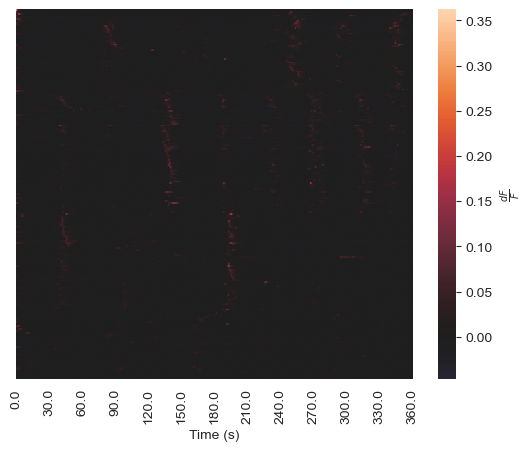

In [43]:
#Plot FC raster
raster_plot(concat_cxta, xtick_range=360, xtick_freq=13)

In [ ]:
#Plot Recall raster
raster_plot(concat_cxta, xtick_range=300, xtick_freq=13)

### Plotting shock eta

In [50]:
def multi_event_eta(data, events=None, window=10, ci='bci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 7.5)

    def event_interpolation(data, events_): #3601 for fc
        interp = scipy.interpolate.interp1d(timestamps[:3601], data, kind='cubic')
        within_eta_ = np.zeros((len(events_), number_of_indices))
        for i, event in enumerate(events_):
            time_period = np.linspace(event - (window / 2), event + window, number_of_indices)
            within_eta_[i] = interp(time_period)
        return np.average(within_eta_, axis=0)

    across_eta_ = np.zeros((len(data), number_of_indices))

    # If there's only one event, repeat it for each curve
    if len(events) == 1:
        events = events * len(data)

    for j, curve in enumerate(data):
        across_eta_[j] = event_interpolation(curve, events[j])

    average_trace = np.average(across_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = tci(across_eta_)
    elif ci == 'bci':
        c_int = bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration=8)  # change to be dependent on the sampling rate

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    time = np.linspace(-window / 2, window, number_of_indices)
    ax.plot(time, average_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    if ax is None:
        return fig, ax, across_eta_
    else:
        return ax, across_eta_

In [9]:
concat_cxta

array([[ 3.623633e-01,  3.391954e-01,  3.197538e-01, ..., -2.288933e-03,
        -3.965848e-03, -3.596301e-04],
       [ 1.665023e-01,  1.483221e-01,  1.246742e-01, ..., -2.892369e-03,
        -3.295809e-03,  1.255237e-03],
       [ 1.582349e-02,  2.204848e-02,  2.368530e-02, ..., -4.190451e-03,
         2.527734e-03,  2.250484e-04],
       ...,
       [ 2.523212e-03,  9.880100e-03,  7.482624e-03, ..., -1.447856e-03,
        -5.235522e-04, -2.952263e-03],
       [ 3.865997e-03,  2.714545e-03,  1.474263e-03, ..., -1.605025e-04,
         8.546383e-03,  3.277041e-03],
       [ 1.466393e-02,  1.679055e-02,  1.498505e-02, ..., -1.621365e-03,
         1.258137e-03,  3.581048e-04]])

In [1]:
fig, axs = plt.subplots()
ax, across_eta_ = multi_event_eta(data=z_cxta[1:, ], events=[[120, 180, 240, 300], ], window=10, ci='bci', sig_duration=8, ax=axs)
#multi_event_eta(data=z_cxtb[1:, ], events=[[120, 180, 240, 300], ], window=10, ci='bci', sig_duration=8, ax=axs)
axs.set_xlabel('Time (seconds)')
axs.set_ylabel(r'$\frac{dF}{F}$ (%)')
axs.grid(False)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
#axs.set_ylim([-5,50])
axs.axvline(0, linestyle='--', color='black', linewidth=0.7)

NameError: name 'plt' is not defined

In [34]:
np.save('/Users/suthardr/Desktop/recall_cxtb_zscore_all_mice_shock_28.npy', across_eta_)

In [ ]:
astro3_day2.behavior_analysis()

In [41]:
astro3_day2.freeze_vector

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
def freezing_eta(data, events=None, window=10, ci='bci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 7.5)

    def event_interpolation(data, events_): #3601 for fc
        interp = scipy.interpolate.interp1d(timestamps[:3303], data, kind='cubic')
        within_eta_ = np.zeros((len(events_), number_of_indices))
        for i, event in enumerate(events_):
            time_period = np.linspace(event - (window / 2), event + window, number_of_indices)
            within_eta_[i] = interp(time_period)
        return np.average(within_eta_, axis=0)

    across_eta_ = np.zeros((len(data), number_of_indices))

    # If there's only one event, repeat it for each curve
    if len(events) == 1:
        events = events * len(data)

    for j, curve in enumerate(data):
        across_eta_[j] = event_interpolation(curve, events[j])

    average_trace = np.average(across_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = tci(across_eta_)
    elif ci == 'bci':
        c_int = bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration=8)  # change to be dependent on the sampling rate

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    time = np.linspace(-window / 2, window, number_of_indices)
    ax.plot(time, average_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    if ax is None:
        return fig, ax, across_eta_
    else:
        return ax, across_eta_

In [9]:
def single_cell_shock_ci(data, timestamps, events=None, window=10, ci='bci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 15)

    interp = scipy.interpolate.interp1d(timestamps, data, kind='cubic')
    within_eta_ = np.zeros((len(events), number_of_indices))
    for i, event_ in enumerate(events):
        time_period = np.linspace(event_ - (window / 2), event_ + window, number_of_indices)
        within_eta_[i] = interp(time_period)

    across_eta_ = np.average(within_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = tci(within_eta_)
    elif ci == 'bci':
        c_int = bci(within_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    time = np.linspace(-window / 2, window, number_of_indices)

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(time, across_eta_, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration) # change to be dependent on the sampling rate

    if len(start_indices) != 0:
        sig = True
    else:
        sig = False

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    return ax, across_eta_, sig


In [10]:
def plot_all_shock_ci(data): #use z_traces, plots all single cells shock eta + ci to determine 'shock responsive' cells
    list_of_sig = []
    for i in range(len(data)):
        ax, across_eta_, sig = single_cell_shock_ci(data=data[i,:], timestamps=timestamps, events=[120,180,240,300], sig_duration=8, window=15, ci='tci')
        if sig:
            list_of_sig.append(i) #tells you the index of the cells that are shock-responsive
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.axvline(0, linestyle='--', color='black')
    return list_of_sig

In [11]:
list_of_sig = plot_all_shock_ci(z_cxta)

ValueError: x and y arrays must be equal in length along interpolation axis.